<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/xAI_excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap lime

# Customer Churn Prediction (Industry Standard) - Telecom

In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

import warnings
warnings.filterwarnings('ignore')


# Load Practical Dataset: Telco Customer Chrun

In [5]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print ("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(df.columns)
df['Churn'].value_counts()

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


,count
Churn,
No,5174
Yes,1869


# Data Pre-Processing

In [10]:
# Drop customerID (not useful)
df = df.drop('customerID', axis=1)

In [11]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [12]:
#Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
  df[col] = le.fit_transform(df[col])

In [14]:
df.head(5)
df.shape

(7032, 20)

In [16]:
#Target variable
X = df.drop("Churn", axis=1)
y = df["Churn"]

feature_names = X.columns.tolist()

# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

In [19]:
# Check imbalance

y_train.value_counts(normalize=True)

# or
y_train.mean(), y_test.mean()

(np.float64(0.2657777777777778), np.float64(0.2658137882018479))

# Model Training

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Modle Training Completed")

Modle Training Completed


# PDP & ICE (GLOBAL + LOCAL BEHAVIOUR)


 Generating PDPs & ICE plots...


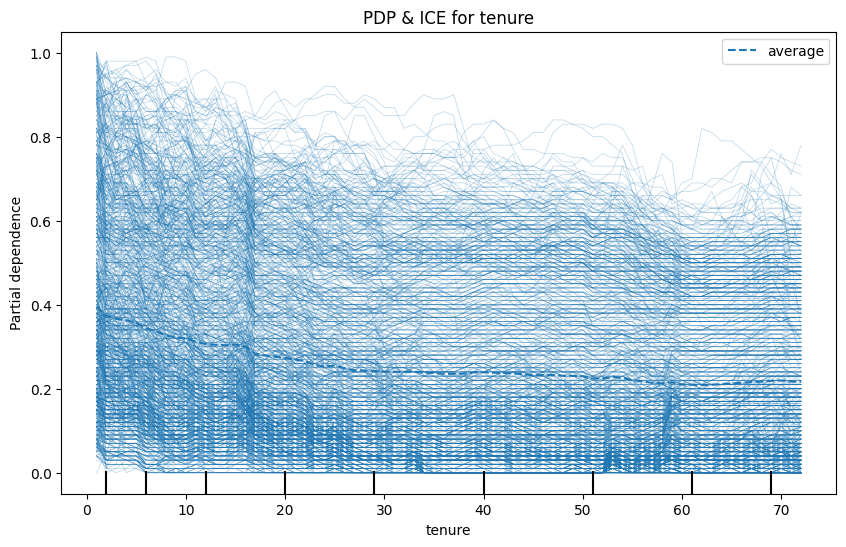

In [25]:
print ("\n Generating PDPs & ICE plots...")
feature_to_plot = "tenure"  # business meaningful feature

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=[feature_to_plot],
    kind="both",   # PDP
    ax=ax
)

plt.title(f"PDP & ICE for {feature_to_plot}")
plt.show()


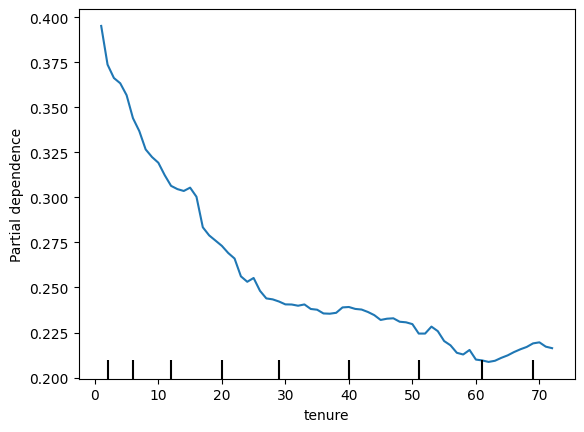

In [28]:
# Plot PDP for clarity
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["tenure"],
    kind="average"
)

What it shows:
X-axis → tenure (months)
Y-axis → predicted churn probability

📉 curve:
Starts around ~0.40 (high churn) at low tenure

Drops steadily to ~0.20 (low churn) as tenure increases

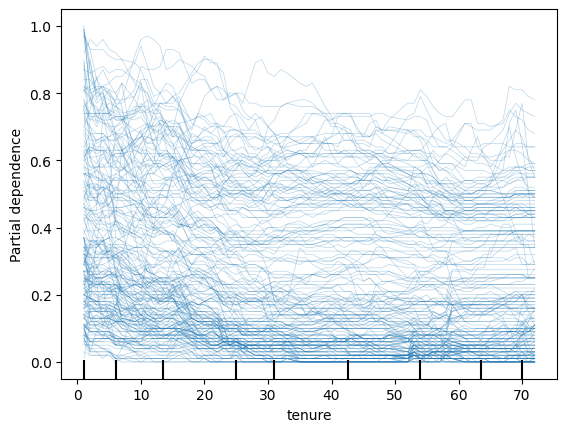

In [29]:
# Plot ICE for zoomed understanding
PartialDependenceDisplay.from_estimator(
    model,
    X_sample,
    features=["tenure"],
    kind="individual"
)

Each line = one customer.
Shows how churn probability changes with tenure for that customer
1. Majority trend (important)
Most lines slope downward
👉 Confirms PDP trend → tenure reduces churn

2. Spread of lines (VERY important)
Lines are widely spread vertically

👉 This means:

❗ Customers behave differently
❗ Tenure alone does NOT explain churn fully

3. Some flat / irregular lines

👉 Means:

For some customers, tenure has little impact
Other features dominate (e.g., contract, charges)


“While tenure globally reduces churn probability, ICE plots show significant variation across customers, indicating that churn behavior is influenced by multiple interacting factors. Tenure is important but not sufficient alone.”

# Permutation Feature Importance (PFI)

“How much does model performance drop if we randomly shuffle a feature?”

Calculating Permutation Feature Importance
            Feature  Importance
4            tenure    0.019048
14         Contract    0.015210
11      TechSupport    0.007818
7   InternetService    0.005899
17   MonthlyCharges    0.005402
1     SeniorCitizen    0.004051
8    OnlineSecurity    0.003412
18     TotalCharges    0.002203
13  StreamingMovies    0.002061
3        Dependents    0.001706


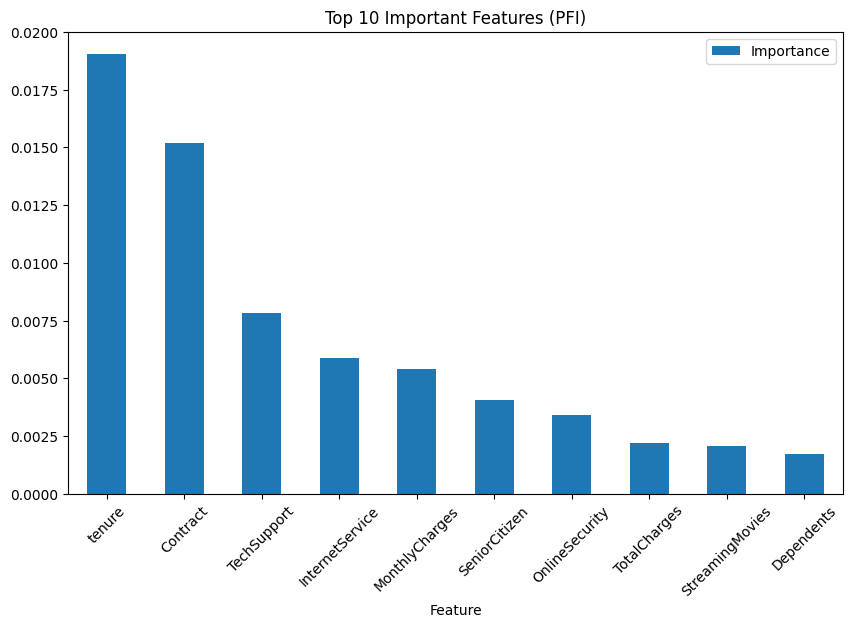

In [31]:
print("Calculating Permutation Feature Importance")

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

importance_df.head(10).plot.bar(x='Feature', y='Importance', figsize=(10, 6))
plt.title('Top 10 Important Features (PFI)')
plt.xticks(rotation=45)
plt.show()

🔑 1. tenure is #1 (Strong Signal)
Highest importance (~0.019)

👉 Meaning:

Model heavily relies on tenure
Removing it significantly degrades prediction

✔ Matches your PDP (earlier)
✔ Matches telecom domain knowledge

🔑 2. Contract is #2 (Very Important)

👉 Interpretation:

Contract type strongly affects churn
Typically:
Month-to-month → high churn
Long-term → low churn
🔑 3. TechSupport / InternetService

👉 These are service quality indicators

Poor support → higher churn
Certain internet types → dissatisfaction
🔑 4. MonthlyCharges

👉 Moderate importance

Higher cost → higher churn risk
But not as dominant as tenure
⚠️ 5. TotalCharges is LOW (Important Insight)

You might expect it to be high—but it's not.

👉 Why?

Because TotalCharges ≈ tenure × MonthlyCharges

So:

Model already gets this info from:
tenure
MonthlyCharges

👉 This is feature redundancy (correlation effect)

# LIME (Local Interpretation)

“Why did the model predict churn for THIS specific customer?”

In [32]:
print("\nGenerating LIME Explanations")
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    mode='classification'
)


Generating LIME Explanations


In [39]:
instance = X_train.iloc[99]  # each row has one customer detail, pick any row

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba
)

exp.show_in_notebook(show_table=True)

In [44]:
# Explain for multiple customer

for i in [1, 5, 10]:
    exp = explainer.explain_instance(
        data_row = X_test.iloc[i].values,
        predict_fn = model.predict_proba,
    )
    exp.show_in_notebook()

In [45]:
model.predict_proba(X_train)

array([[0.94, 0.06],
       [0.98, 0.02],
       [0.98, 0.02],
       ...,
       [0.94, 0.06],
       [0.97, 0.03],
       [0.  , 1.  ]])



1.   Business Context
  - Predict which customer will churn
2.   PDP insight
    Show how tenure impacts churn probability
  - Increasing tenure -> usually lower churn
3.  ICE Insight
  Individual customers behave differently
  - Not all follow same trend
4.  PFI insight:
    Top drivers of chrun
    - tenure, MonthlyCharges, Contract

5.   LIME INSIGHT
  Explains one specific customer
  - why this customer is predicted to churn




# SHAP

Running SHAP


100%|===================| 11246/11250 [12:00<00:00]       

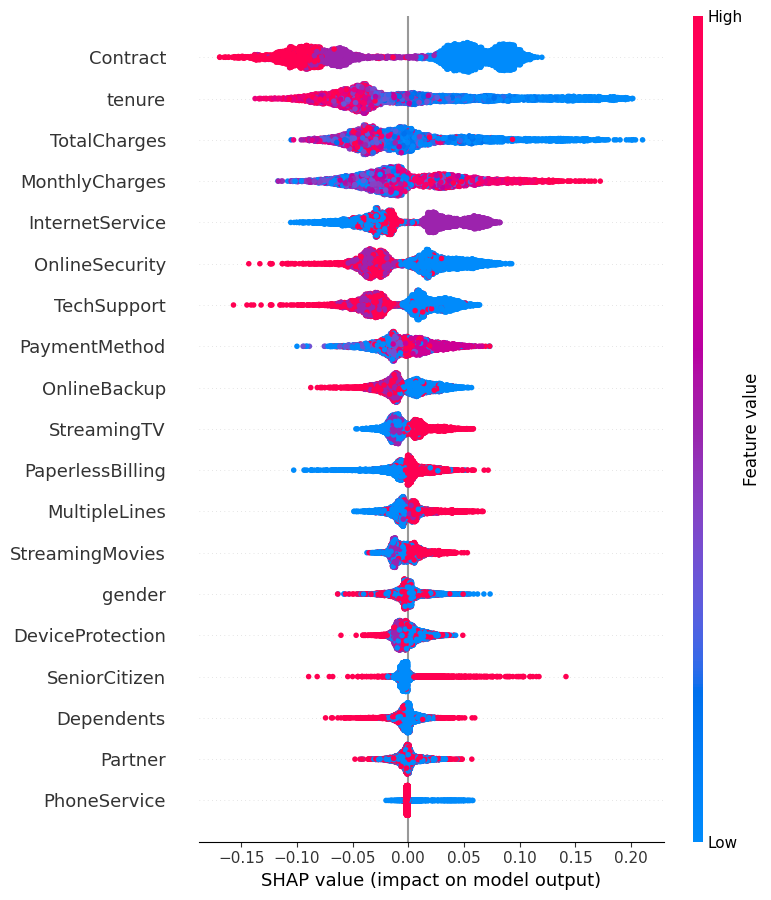

In [46]:
print("Running SHAP")
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train,check_additivity=False)

if len(shap_values.values.shape) == 3:
   shap_vals = shap_values.values[:, :, 1]
else:
  shap_vals = shap_values.values

shap.summary_plot(shap_vals, X_train)

In [48]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_vals[0],
    X_train.iloc[0]
)

In [1]:
print("""
====================== XAI SESSION GUIDE ======================

1. BUSINESS CONTEXT:
   Predict customer churn and identify key drivers
   → Enables targeted retention strategies

---------------------- GLOBAL EXPLAINABILITY ----------------------

2. PDP (Partial Dependence Plot):
   - Shows average effect of a feature on churn
   - Example: Increasing tenure → lower churn risk
   - Use: Business storytelling & trend analysis

3. PFI (Permutation Feature Importance):
   - Measures drop in model performance when feature is shuffled
   - Identifies truly important features
   - Example: tenure, Contract, MonthlyCharges

---------------------- LOCAL + VARIATION ----------------------

4. ICE (Individual Conditional Expectation):
   - Shows how predictions vary per customer
   - Reveals heterogeneity (not all customers behave the same)
   - Use: Segment-level understanding

5. LIME (Local Interpretable Model-Agnostic Explanation):
   - Explains a single prediction
   - Answers: “Why did THIS customer churn?”
   - Use: Debugging individual cases

6. SHAP (SHapley Additive Explanations):
   - Global: Feature importance + direction
   - Local: Exact contribution per feature
   - Based on game theory → most reliable method
   - Use: Production-grade explainability

---------------------- KEY CHALLENGES ----------------------

- Correlated features → misleading PDP/PFI
- LIME instability (sampling variance)
- SHAP computational cost (needs optimization)
- Feature importance ≠ causation (critical!)

---------------------- WHEN TO USE WHAT ----------------------

PDP   → Understand global trends (business view)
ICE   → Analyze individual variability
PFI   → Validate feature importance (model impact)
LIME  → Debug single prediction
SHAP  → Unified global + local explanation (best practice)

==============================================================
""")


====================== XAI SESSION GUIDE ======================

1. BUSINESS CONTEXT:
   Predict customer churn and identify key drivers
   → Enables targeted retention strategies

---------------------- GLOBAL EXPLAINABILITY ----------------------

2. PDP (Partial Dependence Plot):
   - Shows average effect of a feature on churn
   - Example: Increasing tenure → lower churn risk
   - Use: Business storytelling & trend analysis

3. PFI (Permutation Feature Importance):
   - Measures drop in model performance when feature is shuffled
   - Identifies truly important features
   - Example: tenure, Contract, MonthlyCharges

---------------------- LOCAL + VARIATION ----------------------

4. ICE (Individual Conditional Expectation):
   - Shows how predictions vary per customer
   - Reveals heterogeneity (not all customers behave the same)
   - Use: Segment-level understanding

5. LIME (Local Interpretable Model-Agnostic Explanation):
   - Explains a single prediction
   - Answers: “Why did